In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style and configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

import warnings
warnings.filterwarnings("ignore")


In [9]:
# Load the dataset
df = pd.read_csv('../data/raw/data.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nData Types and Missing Values:")
df.info()

print("\nFirst Five Rows:")
display(df.head())


DATASET OVERVIEW
Rows: 95662
Columns: 16

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 1

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"\nNumerical Columns: {len(numerical_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")


Numerical Columns: 5
Categorical Columns: 11


In [11]:
print("=" * 60)
print("NUMERICAL SUMMARY STATISTICS")
print("=" * 60)

display(df[numerical_cols].describe().T)

if len(categorical_cols) > 0:

    print("=" * 60)
    print("CATEGORICAL SUMMARY STATISTICS")
    print("=" * 60)

    display(df[categorical_cols].describe().T)

NUMERICAL SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


CATEGORICAL SUMMARY STATISTICS


,count,unique,top,freq
TransactionId,95662,95662,TransactionId_76871,1
BatchId,95662,94809,BatchId_67019,28
AccountId,95662,3633,AccountId_4841,30893
SubscriptionId,95662,3627,SubscriptionId_3829,32630
CustomerId,95662,3742,CustomerId_7343,4091
CurrencyCode,95662,1,UGX,95662
ProviderId,95662,6,ProviderId_4,38189
ProductId,95662,23,ProductId_6,32635
ProductCategory,95662,9,financial_services,45405
ChannelId,95662,4,ChannelId_3,56935


TARGET DISTRIBUTION


FraudResult
0    95469
1      193
Name: count, dtype: int64

FraudResult
0    99.8
1     0.2
Name: proportion, dtype: float64

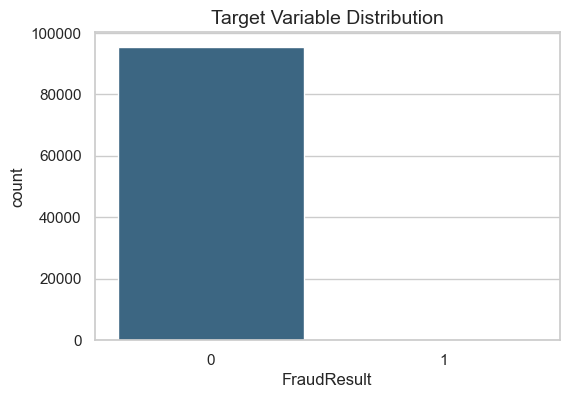

In [ ]:
target_col = "FraudResult"  

if target_col in df.columns:

    print("=" * 60)
    print("TARGET DISTRIBUTION")
    print("=" * 60)

    display(df[target_col].value_counts())

    display(
        round(
            df[target_col]
            .value_counts(normalize=True) * 100,
            2
        )
    )

    plt.figure(figsize=(6, 4))
    sns.countplot(
        x=target_col,
        data=df,
        palette="viridis"
    )
    plt.title("Target Variable Distribution")
    plt.show()

else:
    print(
        f"\nTarget column '{target_col}' "
        "not found. Skipping target analysis."
    )

NUMERICAL FEATURE DISTRIBUTIONS


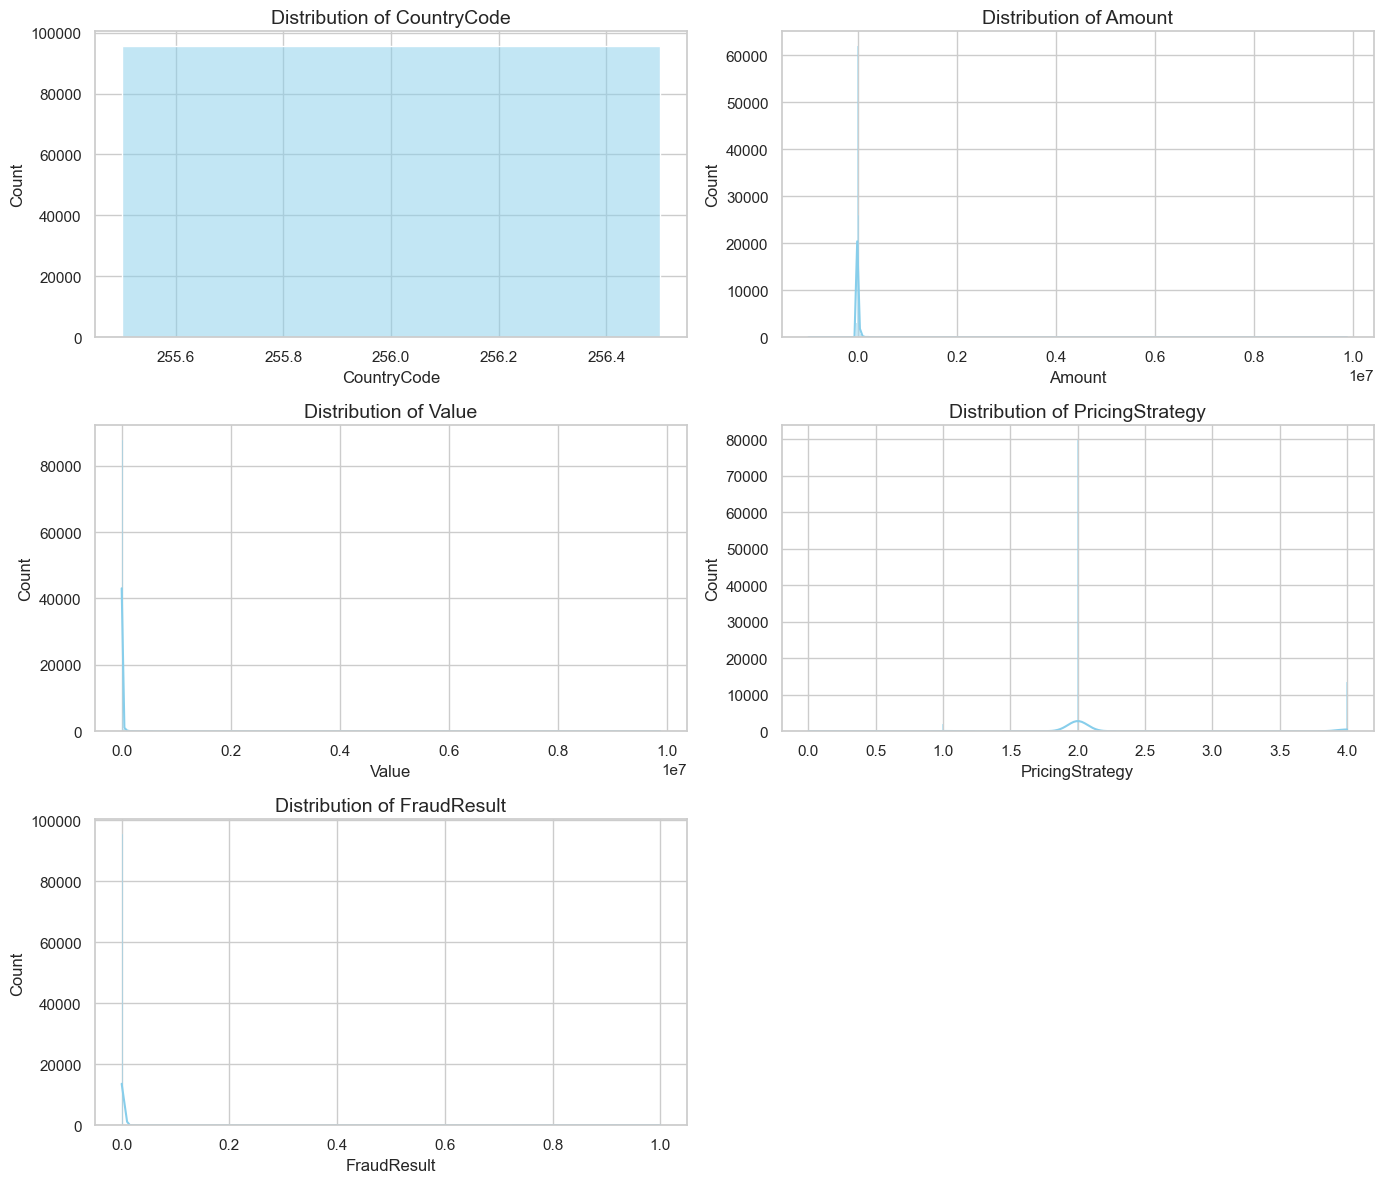

In [15]:
print("=" * 60)
print("NUMERICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

n_cols = 2
n_rows = int(np.ceil(len(numerical_cols[:6]) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, n_rows * 4)
)

axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_cols[:6]):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(
        f"Distribution of {col}"
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [17]:
print("=" * 60)
print("FEATURE SKEWNESS")
print("=" * 60)

skewness = (
    df[numerical_cols]
    .skew()
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

display(skewness.to_frame("Skewness"))

FEATURE SKEWNESS


,Skewness
Value,51.291086
Amount,51.098490
FraudResult,22.196295
PricingStrategy,1.659057
CountryCode,0.000000


CATEGORICAL FEATURE DISTRIBUTIONS


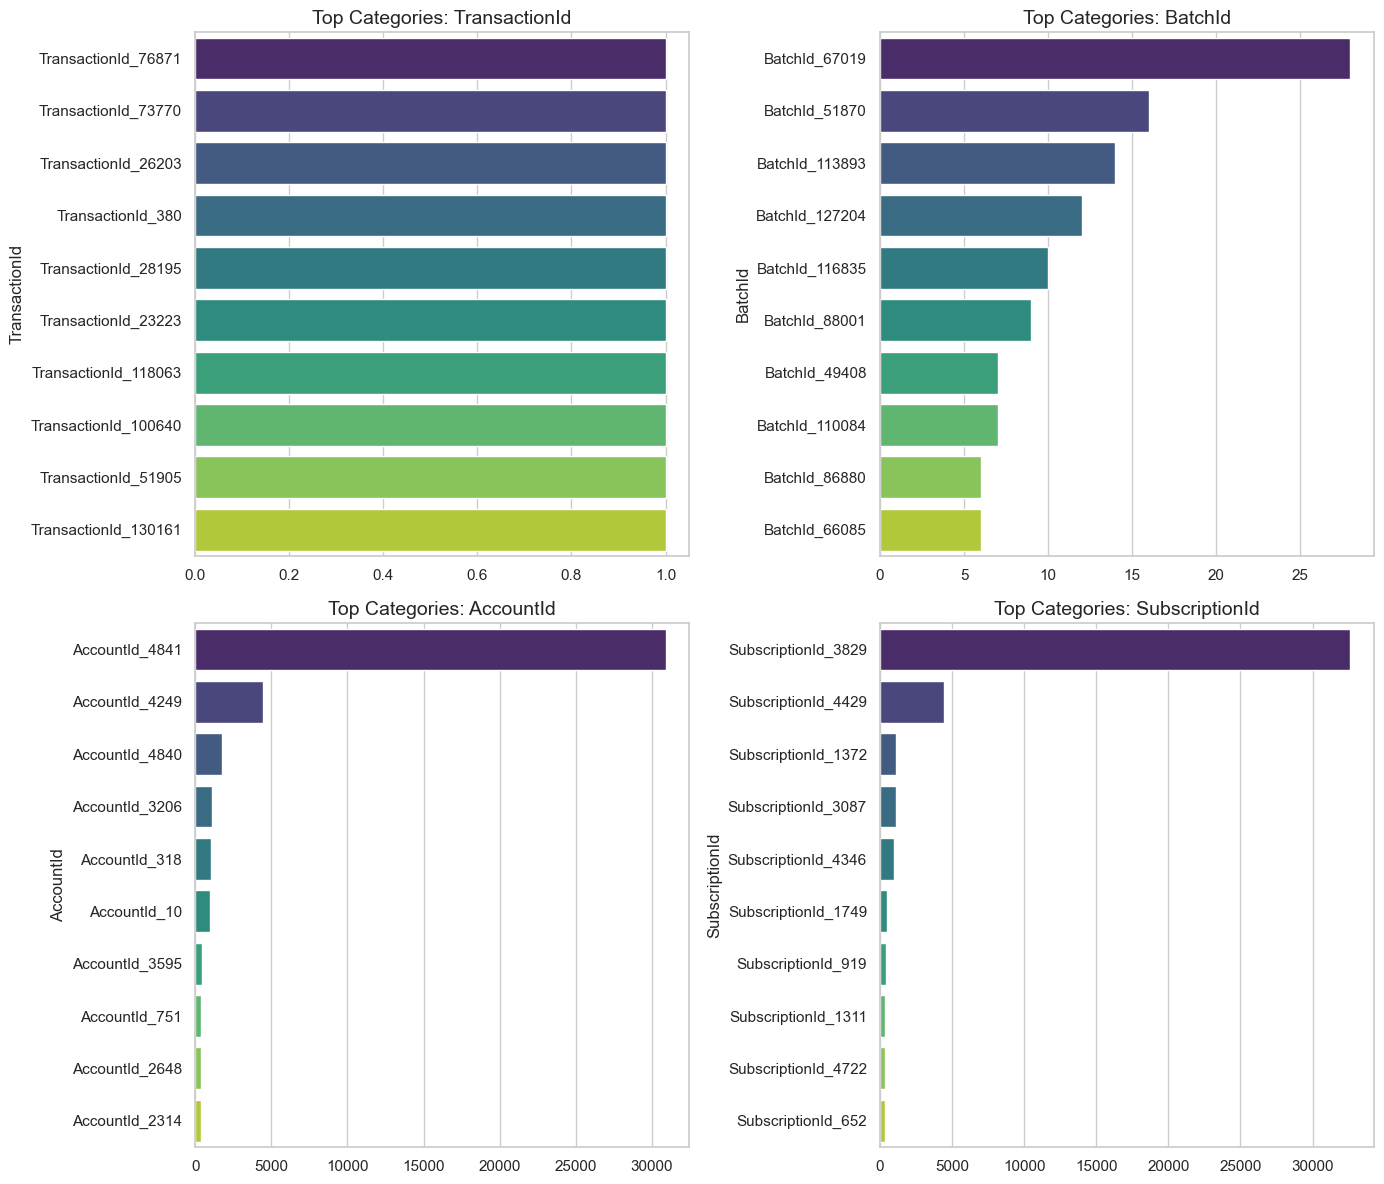

In [18]:
# =====================================================
# CATEGORICAL FEATURE DISTRIBUTIONS
# =====================================================

if len(categorical_cols) > 0:

    print("=" * 60)
    print("CATEGORICAL FEATURE DISTRIBUTIONS")
    print("=" * 60)

    cat_plots = min(len(categorical_cols), 4)

    fig, axes = plt.subplots(
        int(np.ceil(cat_plots / 2)),
        2,
        figsize=(14, cat_plots * 3)
    )

    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(categorical_cols[:cat_plots]):

        top_categories = (
            df[col]
            .value_counts()
            .head(10)
        )

        sns.barplot(
            x=top_categories.values,
            y=top_categories.index,
            ax=axes[i],
            palette="viridis"
        )

        axes[i].set_title(
            f"Top Categories: {col}"
        )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


CORRELATION ANALYSIS


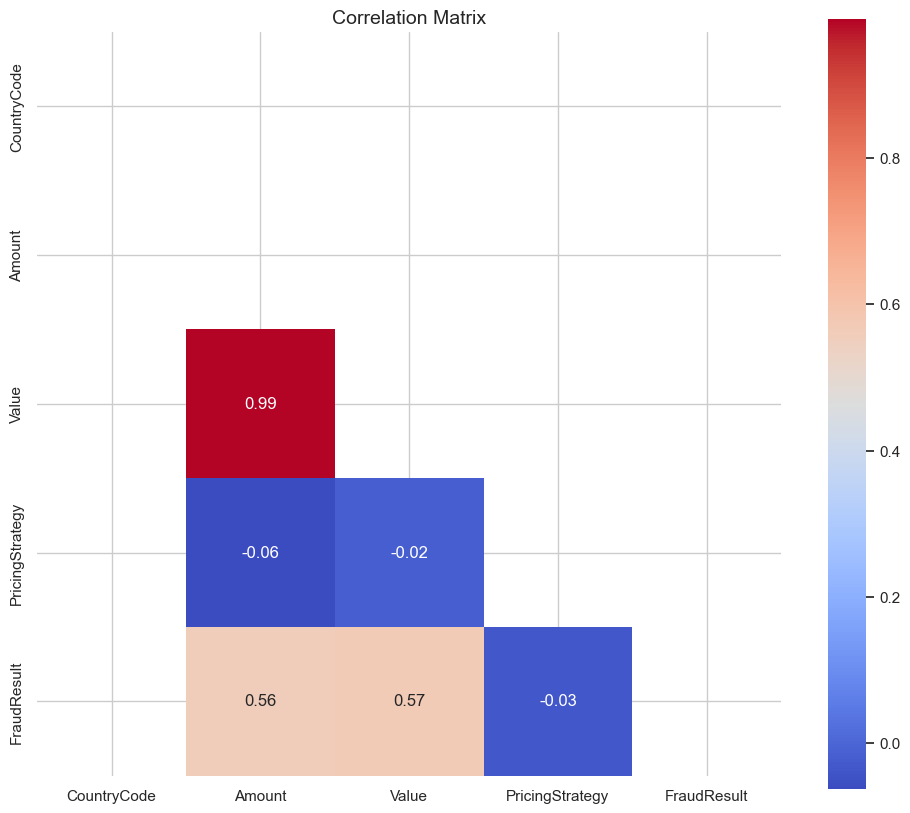

In [19]:
# =====================================================
# CORRELATION ANALYSIS
# =====================================================

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True
)

plt.title(
    "Correlation Matrix"
)

plt.show()


In [20]:
# =====================================================
# TOP CORRELATED FEATURE PAIRS
# =====================================================

upper = corr_matrix.abs().where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

strong_corr = (
    upper.stack()
    .sort_values(
        ascending=False
    )
    .reset_index()
)

strong_corr.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

print("Top Correlated Features")

display(strong_corr.head(15))

Top Correlated Features


,Feature 1,Feature 2,Correlation
0,Amount,Value,0.989692
1,Value,FraudResult,0.566739
2,Amount,FraudResult,0.557370
3,Amount,PricingStrategy,0.061931
4,PricingStrategy,FraudResult,0.033821
5,Value,PricingStrategy,0.017020


In [21]:
# =====================================================
# MISSING VALUE ANALYSIS
# =====================================================

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage":
        round(
            df.isnull().mean() * 100,
            2
        )
})

missing_df = missing_df[
    missing_df["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

if len(missing_df) > 0:

    display(missing_df)

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=missing_df.reset_index(),
        x="Missing Percentage",
        y="index",
        palette="crest"
    )

    plt.title(
        "Missing Values by Feature"
    )

    plt.xlabel(
        "Missing Percentage (%)"
    )

    plt.ylabel("Feature")

    plt.show()

else:
    print("No missing values detected.")



MISSING VALUE ANALYSIS
No missing values detected.


OUTLIER DETECTION


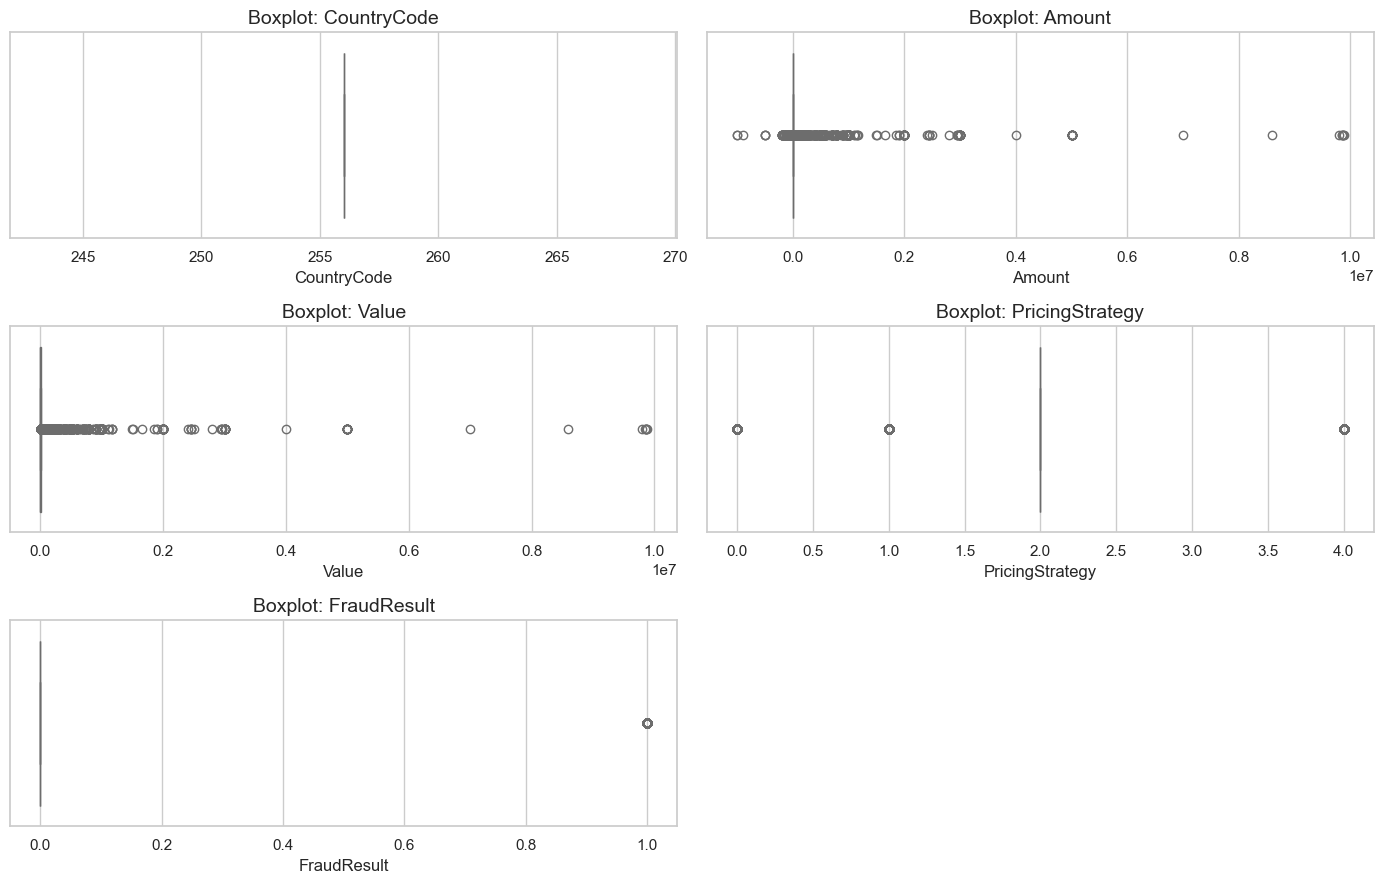

In [22]:
# =====================================================
# OUTLIER DETECTION - BOXPLOTS
# =====================================================

print("=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

n_rows = int(
    np.ceil(
        len(numerical_cols[:6]) / 2
    )
)

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(14, n_rows * 3)
)

axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_cols[:6]):

    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color="salmon"
    )

    axes[i].set_title(
        f"Boxplot: {col}"
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [23]:
# =====================================================
# OUTLIER QUANTIFICATION (IQR)
# =====================================================

outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = (
        Q1 - 1.5 * IQR
    )

    upper_bound = (
        Q3 + 1.5 * IQR
    )

    outliers = df[
        (df[col] < lower_bound)
        |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Outlier Count":
            len(outliers),
        "Outlier Percentage":
            round(
                len(outliers)
                / len(df) * 100,
                2
            )
    })

outlier_df = pd.DataFrame(
    outlier_summary
).sort_values(
    "Outlier Percentage",
    ascending=False
)

print("Outlier Summary")

display(outlier_df)

Outlier Summary


,Feature,Outlier Count,Outlier Percentage
1,Amount,24441,25.55
3,PricingStrategy,15814,16.53
2,Value,9021,9.43
4,FraudResult,193,0.20
0,CountryCode,0,0.00


In [24]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"{col}: Constant Feature")

CurrencyCode: Constant Feature
CountryCode: Constant Feature


# Top 6 Insights from EDA

## 1. Severe Class Imbalance in Fraud Detection
The target variable (`FraudResult`) is highly imbalanced. Out of 95,662 transactions, only 193 (0.2%) are fraudulent, while 95,469 (99.8%) are legitimate. This indicates a rare-event classification problem where accuracy alone would be misleading. Future model evaluation should focus on metrics such as Precision, Recall, F1-Score, ROC-AUC, and PR-AUC.

## 2. Transaction Amount and Value Are Extremely Right-Skewed
Both `Amount` and `Value` exhibit extremely high positive skewness (approximately 51), indicating that most transactions are relatively small while a small number of transactions are exceptionally large. This suggests that transformations such as logarithmic scaling, robust scaling, or binning may improve model performance.

## 3. Significant Outliers Exist in Key Financial Variables
Outlier analysis using the IQR method identified a substantial number of outliers:
- `Amount`: 24,441 outliers (25.55%)
- `PricingStrategy`: 15,814 outliers (16.53%)
- `Value`: 9,021 outliers (9.43%)

These outliers may represent unusual customer behavior or potentially fraudulent activity and should be carefully handled during feature engineering.

## 4. Amount and Value Are Nearly Redundant Features
Correlation analysis revealed an extremely strong positive correlation between `Amount` and `Value` (r = 0.99). Since these features capture nearly identical information, retaining both may introduce redundancy. Feature selection techniques should be considered during model development.

## 5. Larger Transactions Show Higher Association with Fraud
Both `Amount` (r = 0.56) and `Value` (r = 0.57) exhibit moderate positive correlations with `FraudResult`. This suggests that larger transaction sizes are more likely to be associated with fraudulent activity, making transaction magnitude an important predictive signal.

## 6. CurrencyCode and CountryCode Are Constant Features
Both `CurrencyCode` and `CountryCode` contain only a single unique value across the entire dataset. Since these features have zero variance, they provide no predictive information and can be safely removed during preprocessing.

---

## Feature Engineering Considerations

Based on the EDA findings, the following preprocessing and feature engineering steps are recommended:

- Remove constant features (`CurrencyCode`, `CountryCode`).
- Create temporal features from `TransactionStartTime` such as hour, day of week, month, and weekend indicators.
- Apply transformations (e.g., log transformation) to highly skewed variables like `Amount` and `Value`.
- Investigate and appropriately handle extreme outliers.
- Consider dropping one of `Amount` or `Value` due to their high correlation.
- Address the severe class imbalance using techniques such as class weighting, resampling, or specialized evaluation metrics.